# Figure 1: Phase Transition Validation

This notebook creates a 3-panel figure validating the phase transition theory in PLS-SVD with missing data.

**Panels:**
- (a) Phase transition curve showing R_x^2 and R_y^2 as functions of normalized signal strength
- (b) 2D phase diagram heatmap with theoretical boundary overlay
- (c) Finite-size sharpening demonstrating transition becomes sharper with increasing N

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from multiprocessing import Pool
from src import ModelParams
from src import _run_experiment_worker, _run_grid_worker, _run_n_worker
from tqdm.notebook import tqdm

# ICML-compatible styling with increased font sizes
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

np.random.seed(42)

## Parameters

The x-axis shows theta/theta_crit, the signal strength normalized by the critical threshold.
- theta/theta_crit < 1: Subcritical regime (no recovery, R^2 = 0)
- theta/theta_crit = 1: Phase transition point
- theta/theta_crit > 1: Supercritical regime (successful recovery)

In [2]:
# ============================================================================
# EXPERIMENT 1A: θ sweep for panel (a)
# ============================================================================
import pickle
import os

# Parameters
N = 1000
Dx = 200
Dy = 50
mx = 0.3
my = 0.4

# Check if results exist
results_dir = '../results'
results_file = os.path.join(results_dir, 'fig1_results.pkl')

if os.path.exists(results_file):
    print("Loading results from file...")
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    data = all_results['theta_sweep']
    results_1a = data['results']
    theta_crit_1a = data['theta_crit']
    print(f"  Loaded! θ_crit = {theta_crit_1a:.3f}\n")
else:
    print("Running Experiment 1A: θ sweep...")
    
    # Get theta_crit
    base_params = ModelParams(N=N, Dx=Dx, Dy=Dy, theta=1.0, mx=mx, my=my)
    theta_crit_1a = base_params.theta_crit
    
    print(f"  θ_crit = {theta_crit_1a:.3f}")
    
    # Sweep theta
    theta_values_1a = np.linspace(0.5 * theta_crit_1a, 2.5 * theta_crit_1a, 25)
    n_trials = 100  # Increased from 60
    
    # Prepare arguments for parallel execution (convert to dicts for pickling)
    args_list = []
    for theta in theta_values_1a:
        params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': mx, 'my': my}
        args_list.append((params_dict, n_trials))
    
    # Run in parallel with single progress bar
    with Pool() as pool:
        results_raw = list(tqdm(pool.imap(_run_experiment_worker, args_list),
                                total=len(args_list), desc="  Exp 1A"))
    
    # Add metadata
    results_1a = []
    for i, result in enumerate(results_raw):
        result['theta'] = theta_values_1a[i]
        result['theta_norm'] = theta_values_1a[i] / theta_crit_1a
        results_1a.append(result)
    
    # Save results (will be combined with other experiments)
    os.makedirs(results_dir, exist_ok=True)
    all_results = {}
    all_results['theta_sweep'] = {
        'results': results_1a,
        'theta_crit': theta_crit_1a,
        'N': N,
        'Dx': Dx,
        'Dy': Dy,
        'mx': mx,
        'my': my
    }
    with open(results_file, 'wb') as f:
        pickle.dump(all_results, f)
    
    print("  Done! Results saved.\n")

Loading results from file...
  Loaded! θ_crit = 0.488



In [3]:
# ============================================================================
# EXPERIMENT 1B: Phase diagram for panel (b)
# ============================================================================

# Parameters
N = 1000
Dx = 150
Dy = 120

# Check if results exist
results_file = os.path.join(results_dir, 'fig1_results.pkl')

if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    if 'phase_diagram' in all_results:
        print("Loading phase diagram results...")
        data = all_results['phase_diagram']
        Rx2_empirical = data['Rx2_empirical']
        Rx2_theoretical = data['Rx2_theoretical']
        theta_grid = data['theta_grid']
        rho_grid = data['rho_grid']
        correlation = data['correlation']
        print(f"  Loaded! Correlation (theory vs empirical): {correlation:.4f}\n")
        
        # Reconstruct theoretical phase boundary function
        alpha_x = N / Dx
        alpha_y = N / Dy
        theta_crit_func = lambda rho: 1 / ((alpha_x * alpha_y)**0.25 * np.sqrt(rho))
    else:
        raise KeyError("phase_diagram not found in results file")
else:
    print("Running Experiment 1C: Phase diagram...")
    
    # Grid - Updated ranges
    theta_grid = np.linspace(0.5, 2.0, 30)
    rho_grid = np.linspace(0.1, 0.95, 30)
    n_trials = 30
    
    # Theoretical phase boundary
    alpha_x = N / Dx
    alpha_y = N / Dy
    theta_crit_func = lambda rho: 1 / ((alpha_x * alpha_y)**0.25 * np.sqrt(rho))
    
    # Prepare arguments for parallel execution (flatten grid, convert to dicts)
    args_list = []
    for i, rho in enumerate(rho_grid):
        m = 1 - np.sqrt(rho)
        for j, theta in enumerate(theta_grid):
            params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': m, 'my': m}
            args_list.append((params_dict, n_trials, i, j))
    
    # Run in parallel with single progress bar
    with Pool() as pool:
        results_raw = list(tqdm(pool.imap(_run_grid_worker, args_list),
                                total=len(args_list), desc="  Exp 1C"))
    
    # Fill matrices
    Rx2_empirical = np.zeros((len(rho_grid), len(theta_grid)))
    Rx2_theoretical = np.zeros((len(rho_grid), len(theta_grid)))
    
    for i, j, rx2_emp, rx2_theory in results_raw:
        Rx2_empirical[i, j] = rx2_emp
        Rx2_theoretical[i, j] = rx2_theory
    
    # Compute correlation
    correlation = np.corrcoef(Rx2_empirical.flatten(), Rx2_theoretical.flatten())[0, 1]
    
    # Save results (add to existing file)
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    all_results['phase_diagram'] = {
        'Rx2_empirical': Rx2_empirical,
        'Rx2_theoretical': Rx2_theoretical,
        'theta_grid': theta_grid,
        'rho_grid': rho_grid,
        'correlation': correlation,
        'N': N,
        'Dx': Dx,
        'Dy': Dy
    }
    with open(results_file, 'wb') as f:
        pickle.dump(all_results, f)
    
    print(f"  Correlation (theory vs empirical): {correlation:.4f}")
    print("  Done! Results saved.\n")

Loading phase diagram results...
  Loaded! Correlation (theory vs empirical): 0.9943



In [4]:
# ============================================================================
# EXPERIMENT 1C: Finite-size sharpening for panel (c)
# ============================================================================

# Different N values
N_configs = [100, 250, 500, 1000, 2000, 5000]
alpha_x = 2.5
alpha_y = 2.5
mx = my = 0.2

# Check if results exist
results_file = os.path.join(results_dir, 'fig1_results.pkl')

if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    if 'finite_size' in all_results:
        print("Loading finite size results...")
        data = all_results['finite_size']
        results_2c = data['results']
        N_configs = data['N_configs']
        alpha_x = data['alpha_x']
        alpha_y = data['alpha_y']
        mx = data['mx']
        my = data['my']
        print(f"  Loaded! N_configs = {N_configs}\n")
    else:
        raise KeyError("finite_size not found in results file")
else:
    print("Running Experiment 2C: Finite-size sharpening...")
    
    # Prepare arguments for all N configurations (convert to dicts)
    args_list = []
    
    for N in N_configs:
        Dx = int(N / alpha_x)
        Dy = int(N / alpha_y)
        
        # Get critical theta
        params_temp = ModelParams(N=N, Dx=Dx, Dy=Dy, theta=1.0, mx=mx, my=my)
        theta_crit = params_temp.theta_crit
        
        # Sweep theta in narrow window around theta_crit
        theta_values = np.linspace(0.85 * theta_crit, 1.15 * theta_crit, 20)
        n_trials = 30
        
        for theta in theta_values:
            params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': mx, 'my': my}
            args_list.append((params_dict, n_trials, N, theta, theta_crit))
    
    # Run in parallel with single progress bar
    with Pool() as pool:
        results_all = list(tqdm(pool.imap(_run_n_worker, args_list),
                                total=len(args_list), desc="  Exp 2C"))
    
    # Organize results by N
    results_2c = {N: [] for N in N_configs}
    for result in results_all:
        results_2c[result['N']].append(result)
    
    # Sort by theta_norm for each N
    for N in N_configs:
        results_2c[N] = sorted(results_2c[N], key=lambda x: x['theta_norm'])
    
    # Save results (add to existing file)
    with open(results_file, 'rb') as f:
        all_results = pickle.load(f)
    all_results['finite_size'] = {
        'results': results_2c,
        'N_configs': N_configs,
        'alpha_x': alpha_x,
        'alpha_y': alpha_y,
        'mx': mx,
        'my': my
    }
    with open(results_file, 'wb') as f:
        pickle.dump(all_results, f)
    
    print("  Done! Results saved.\n")

Loading finite size results...
  Loaded! N_configs = [100, 250, 500, 1000, 2000, 5000]



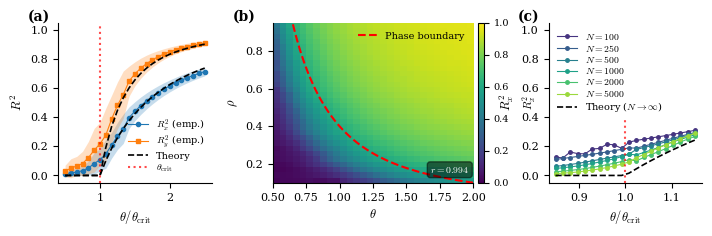


Figure saved: ../figures/fig1_phase_transition_validation.pdf

Dimensions: 7.0 × 2.4 inches (ICML two-column width)

Panel (a): Phase transition with θ_crit = 0.488
Panel (b): Phase diagram with correlation r = 0.9943
Panel (c): Finite-size sharpening (N = 100 to 5000)


In [5]:
# Create figure with GridSpec
fig = plt.figure(figsize=(7.0, 2.0))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1.4, 1],
                       wspace=0.35, left=0.06, right=0.98,
                       bottom=0.16, top=0.96)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

# ============================================================================
# PANEL (a): Phase Transition (θ sweep) - Combined R_x² and R_y²
# ============================================================================
theta_norm_1a = [r['theta_norm'] for r in results_1a]

# R_x² - mean line with circles
ax_a.plot(theta_norm_1a,
          [r['Rx2_pls_mean'] for r in results_1a],
          'o-', markersize=3, linewidth=0.8,
          color='C0', label=r'$R_x^2$ (emp.)')

# R_x² - uncertainty band
ax_a.fill_between(theta_norm_1a,
                  [r['Rx2_pls_mean'] - r['Rx2_pls_std'] for r in results_1a],
                  [r['Rx2_pls_mean'] + r['Rx2_pls_std'] for r in results_1a],
                  color='C0', alpha=0.25, linewidth=0)

# R_y² - mean line with squares
ax_a.plot(theta_norm_1a,
          [r['Ry2_pls_mean'] for r in results_1a],
          's-', markersize=3, linewidth=0.8,
          color='C1', label=r'$R_y^2$ (emp.)')

# R_y² - uncertainty band
ax_a.fill_between(theta_norm_1a,
                  [r['Ry2_pls_mean'] - r['Ry2_pls_std'] for r in results_1a],
                  [r['Ry2_pls_mean'] + r['Ry2_pls_std'] for r in results_1a],
                  color='C1', alpha=0.25, linewidth=0)

# Theory curves
ax_a.plot(theta_norm_1a, [r['Rx2_theory'] for r in results_1a],
          'k--', linewidth=1.2, label='Theory')
ax_a.plot(theta_norm_1a, [r['Ry2_theory'] for r in results_1a],
          'k--', linewidth=1.2)

# Critical threshold marker
ax_a.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
             label=r'$\theta_{\mathrm{crit}}$')

ax_a.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_a.set_ylabel(r'$R^2$')
ax_a.set_ylim([-0.05, 1.05])
ax_a.legend(loc='lower left', bbox_to_anchor=(0.4, 0.0), frameon=False, labelspacing=0.15)
ax_a.text(-0.20, 1.08, '(a)', transform=ax_a.transAxes,
          fontsize=10, fontweight='bold', va='top')

# ============================================================================
# PANEL (b): Phase Diagram - Centerpiece
# ============================================================================
# Show empirical heatmap only (theory correlation > 0.998)
im = ax_b.imshow(Rx2_empirical, 
                 extent=[theta_grid[0], theta_grid[-1], rho_grid[0], rho_grid[-1]],
                 origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)

# Crop to desired ranges
ax_b.set_xlim([0.5, 2.0])
ax_b.set_ylim([0.1, 0.95])

# Phase boundary overlay
rho_fine = np.linspace(0.1, 0.95, 100)
theta_boundary = [theta_crit_func(r) for r in rho_fine]
ax_b.plot(theta_boundary, rho_fine, 'r--', linewidth=1.5, 
          label='Phase boundary')

# Add correlation annotation
ax_b.text(0.98, 0.05, f'$r = {correlation:.3f}$', 
          transform=ax_b.transAxes, fontsize=7, 
          ha='right', va='bottom', color='white',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))

ax_b.set_xlabel(r'$\theta$')
ax_b.set_ylabel(r'$\rho$')
ax_b.legend(loc='upper right', frameon=False)
ax_b.text(-0.20, 1.08, '(b)', transform=ax_b.transAxes,
          fontsize=10, fontweight='bold', va='top')

# Colorbar with better sizing and positioning to avoid overlap
cbar = plt.colorbar(im, ax=ax_b, fraction=0.046, pad=0.02, aspect=25)
cbar.set_label(r'$R_x^2$', fontsize=8, labelpad=8)
cbar.ax.tick_params(labelsize=7)

# ============================================================================
# PANEL (c): Finite-Size Sharpening
# ============================================================================
# Sequential colors for different N values
colors_n = plt.cm.viridis(np.linspace(0.15, 0.85, len(N_configs)))

for i, N in enumerate(N_configs):
    results = results_2c[N]
    theta_norm = [r['theta_norm'] for r in results]
    Rx2_mean = [r['Rx2_pls_mean'] for r in results]
    
    # No error bars (reduce clutter)
    ax_c.plot(theta_norm, Rx2_mean, 'o-',
              markersize=2.5, linewidth=0.8,
              color=colors_n[i], label=f'$N = {N}$')

# Theoretical curve (N → ∞)
theta_norm_theory = [r['theta_norm'] for r in results_2c[N_configs[-1]]]
Rx2_theory = [r['Rx2_theory'] for r in results_2c[N_configs[-1]]]
ax_c.plot(theta_norm_theory, Rx2_theory, 'k--', linewidth=1.2,
          label=r'Theory ($N\to\infty$)', zorder=10)

# Critical threshold marker
ax_c.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7, ymax=0.4)

# Arrow annotation for N increase
# ax_c.annotate('', xy=(0.98, 0.75), xytext=(0.98, 0.25),
#               xycoords='axes fraction',
#               arrowprops=dict(arrowstyle='->', lw=1.2, color='gray'))
# ax_c.text(1.02, 0.5, r'$N \uparrow$', transform=ax_c.transAxes,
#           fontsize=7, color='gray', rotation=90, va='center')

ax_c.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_c.set_ylabel(r'$R_x^2$')
ax_c.set_ylim([-0.05, 1.05])
ax_c.legend(loc='upper left', frameon=False, ncol=1, labelspacing=0.1)
ax_c.text(-0.20, 1.08, '(c)', transform=ax_c.transAxes,
          fontsize=10, fontweight='bold', va='top')

# ============================================================================
# Save figure
# ============================================================================
plt.savefig('../figures/fig1_phase_transition_validation.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Figure saved: ../figures/fig1_phase_transition_validation.pdf")
print("="*70)
print(f"\nDimensions: 7.0 × 2.4 inches (ICML two-column width)")
print(f"\nPanel (a): Phase transition with θ_crit = {theta_crit_1a:.3f}")
print(f"Panel (b): Phase diagram with correlation r = {correlation:.4f}")
print(f"Panel (c): Finite-size sharpening (N = 100 to 5000)")